<a href="https://colab.research.google.com/github/lokendrasinghofficial/Pima-Indians-Diabetes-Case-study/blob/main/Logistic_Regression_Pima_Indians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pima Indians Diabetes Case study
Diabetes is one of the most frequent diseases worldwide and the number of diabetic patients is growing over the years. The main cause of diabetes remains unknown, yet scientists believe that both genetic factors and environmental lifestyle play a major role in diabetes.

Individuals with diabetes face a risk of developing some secondary health issues such as heart diseases and nerve damage. Thus, early detection and treatment of diabetes can prevent complications and assist in reducing the risk of severe health problems.
Even though it's incurable, it can be managed by treatment and medication.

Researchers at the Bio-Solutions lab want to get better understanding of this disease among women and are planning to use machine learning models that will help them to identify patients who are at risk of diabetes.

We will use logistic regression to model the "Pima Indians Diabetes" data set. In particular, all patients here are females at least 21 years old of Pima Indian heritage. This model will predict which people are likely to develop diabetes.

## Data Description:

* Pregnancies: Number of times pregnant
* Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test
* BloodPressure: Diastolic blood pressure (mm Hg)
* SkinThickness: Triceps skinfold thickness (mm)
* Insulin: 2-Hour serum insulin (mu U/ml)
* BMI: Body mass index (weight in kg/(height in m)^2)
* Pedigree: Diabetes pedigree function - A function that scores likelihood of diabetes based on family history.
* Age: Age in years
* Class: Class variable (0: the person is not diabetic or 1: the person is diabetic)

### Import necessary libraries

In [ ]:
# To filter the warnings
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split


# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, roc_auc_score


# this will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Read the dataset

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/Classification Problems/pima-indians-diabetes.csv")

### View the first and last 5 rows of the dataset

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


### Understand the shape of the dataset

In [ ]:
data.shape

(768, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Class          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


* There are 768 observations and 9 columns in the dataset

### Checking for null values in the data

In [ ]:
data.isnull().values.any()

np.False_

* We don't have missing values in the data.

#### Distribution of variables in the data

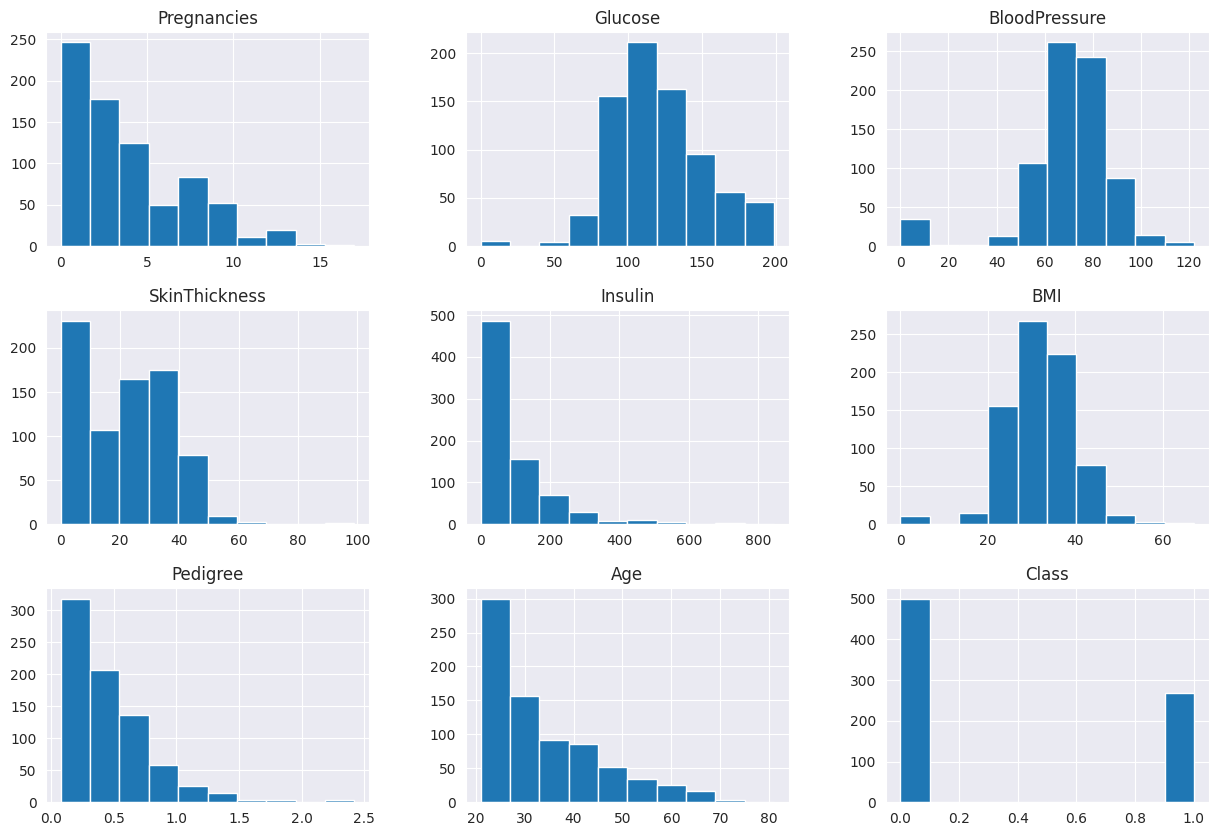

In [ ]:
sns.set_style("darkgrid")
data.hist(figsize=(15, 10))
plt.show()

**NOTE: In this dataset, we notice that some variables—such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI—contain values of 0.**

However, these measurements cannot realistically be zero in a living person. For example:

- Glucose level cannot be 0
- Blood pressure cannot be 0

So, these zeros are likely data entry errors or missing measurements, not real values.

**Steps to fix it:**
* We can see that Glucose, BloodPressure, SkinThickness, Insulin, BMI have obervations with 0 values, which is not possible. These are data entry errors and we should fix it.
* We will replace 0 values in all the columns except Pregnancies and Class with the NaN (this will help us deal with the missing values elegantly)
* We will impute missing (NaN) values with the mean.

In [ ]:
# defining columns where we need to replace 0 with NaN
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Pedigree"]

In [ ]:
# replacing 0 with NaN
data[cols] = data[cols].replace(0, np.nan)

In [ ]:
# let's check missing values in the data again
data.isna().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
Pedigree,0
Age,0
Class,0


In [ ]:
# Let's impute missing values using mean value
data[cols] = data[cols].fillna(data[cols].mean())

In [ ]:
# let's check missing values in the data again
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
Pedigree,0
Age,0
Class,0


* We have imputed all the data entry errors with the mean values.

### Bivariate Analysis

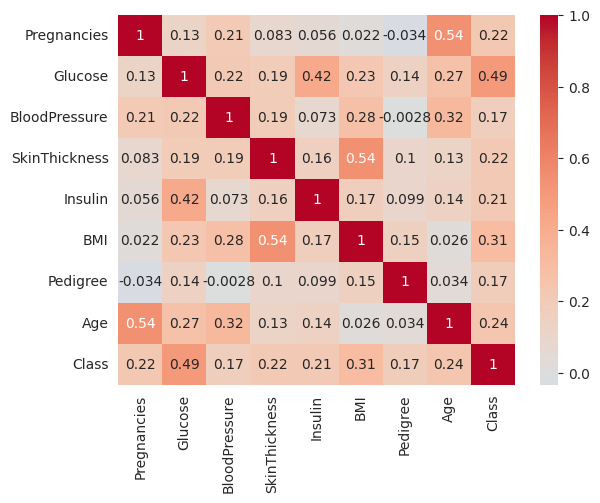

In [ ]:
#Correlation heatmap showing pairwise relationships between numerical variables
corr = data.select_dtypes(include=["number"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

* No significant case of high correlation among variables observed

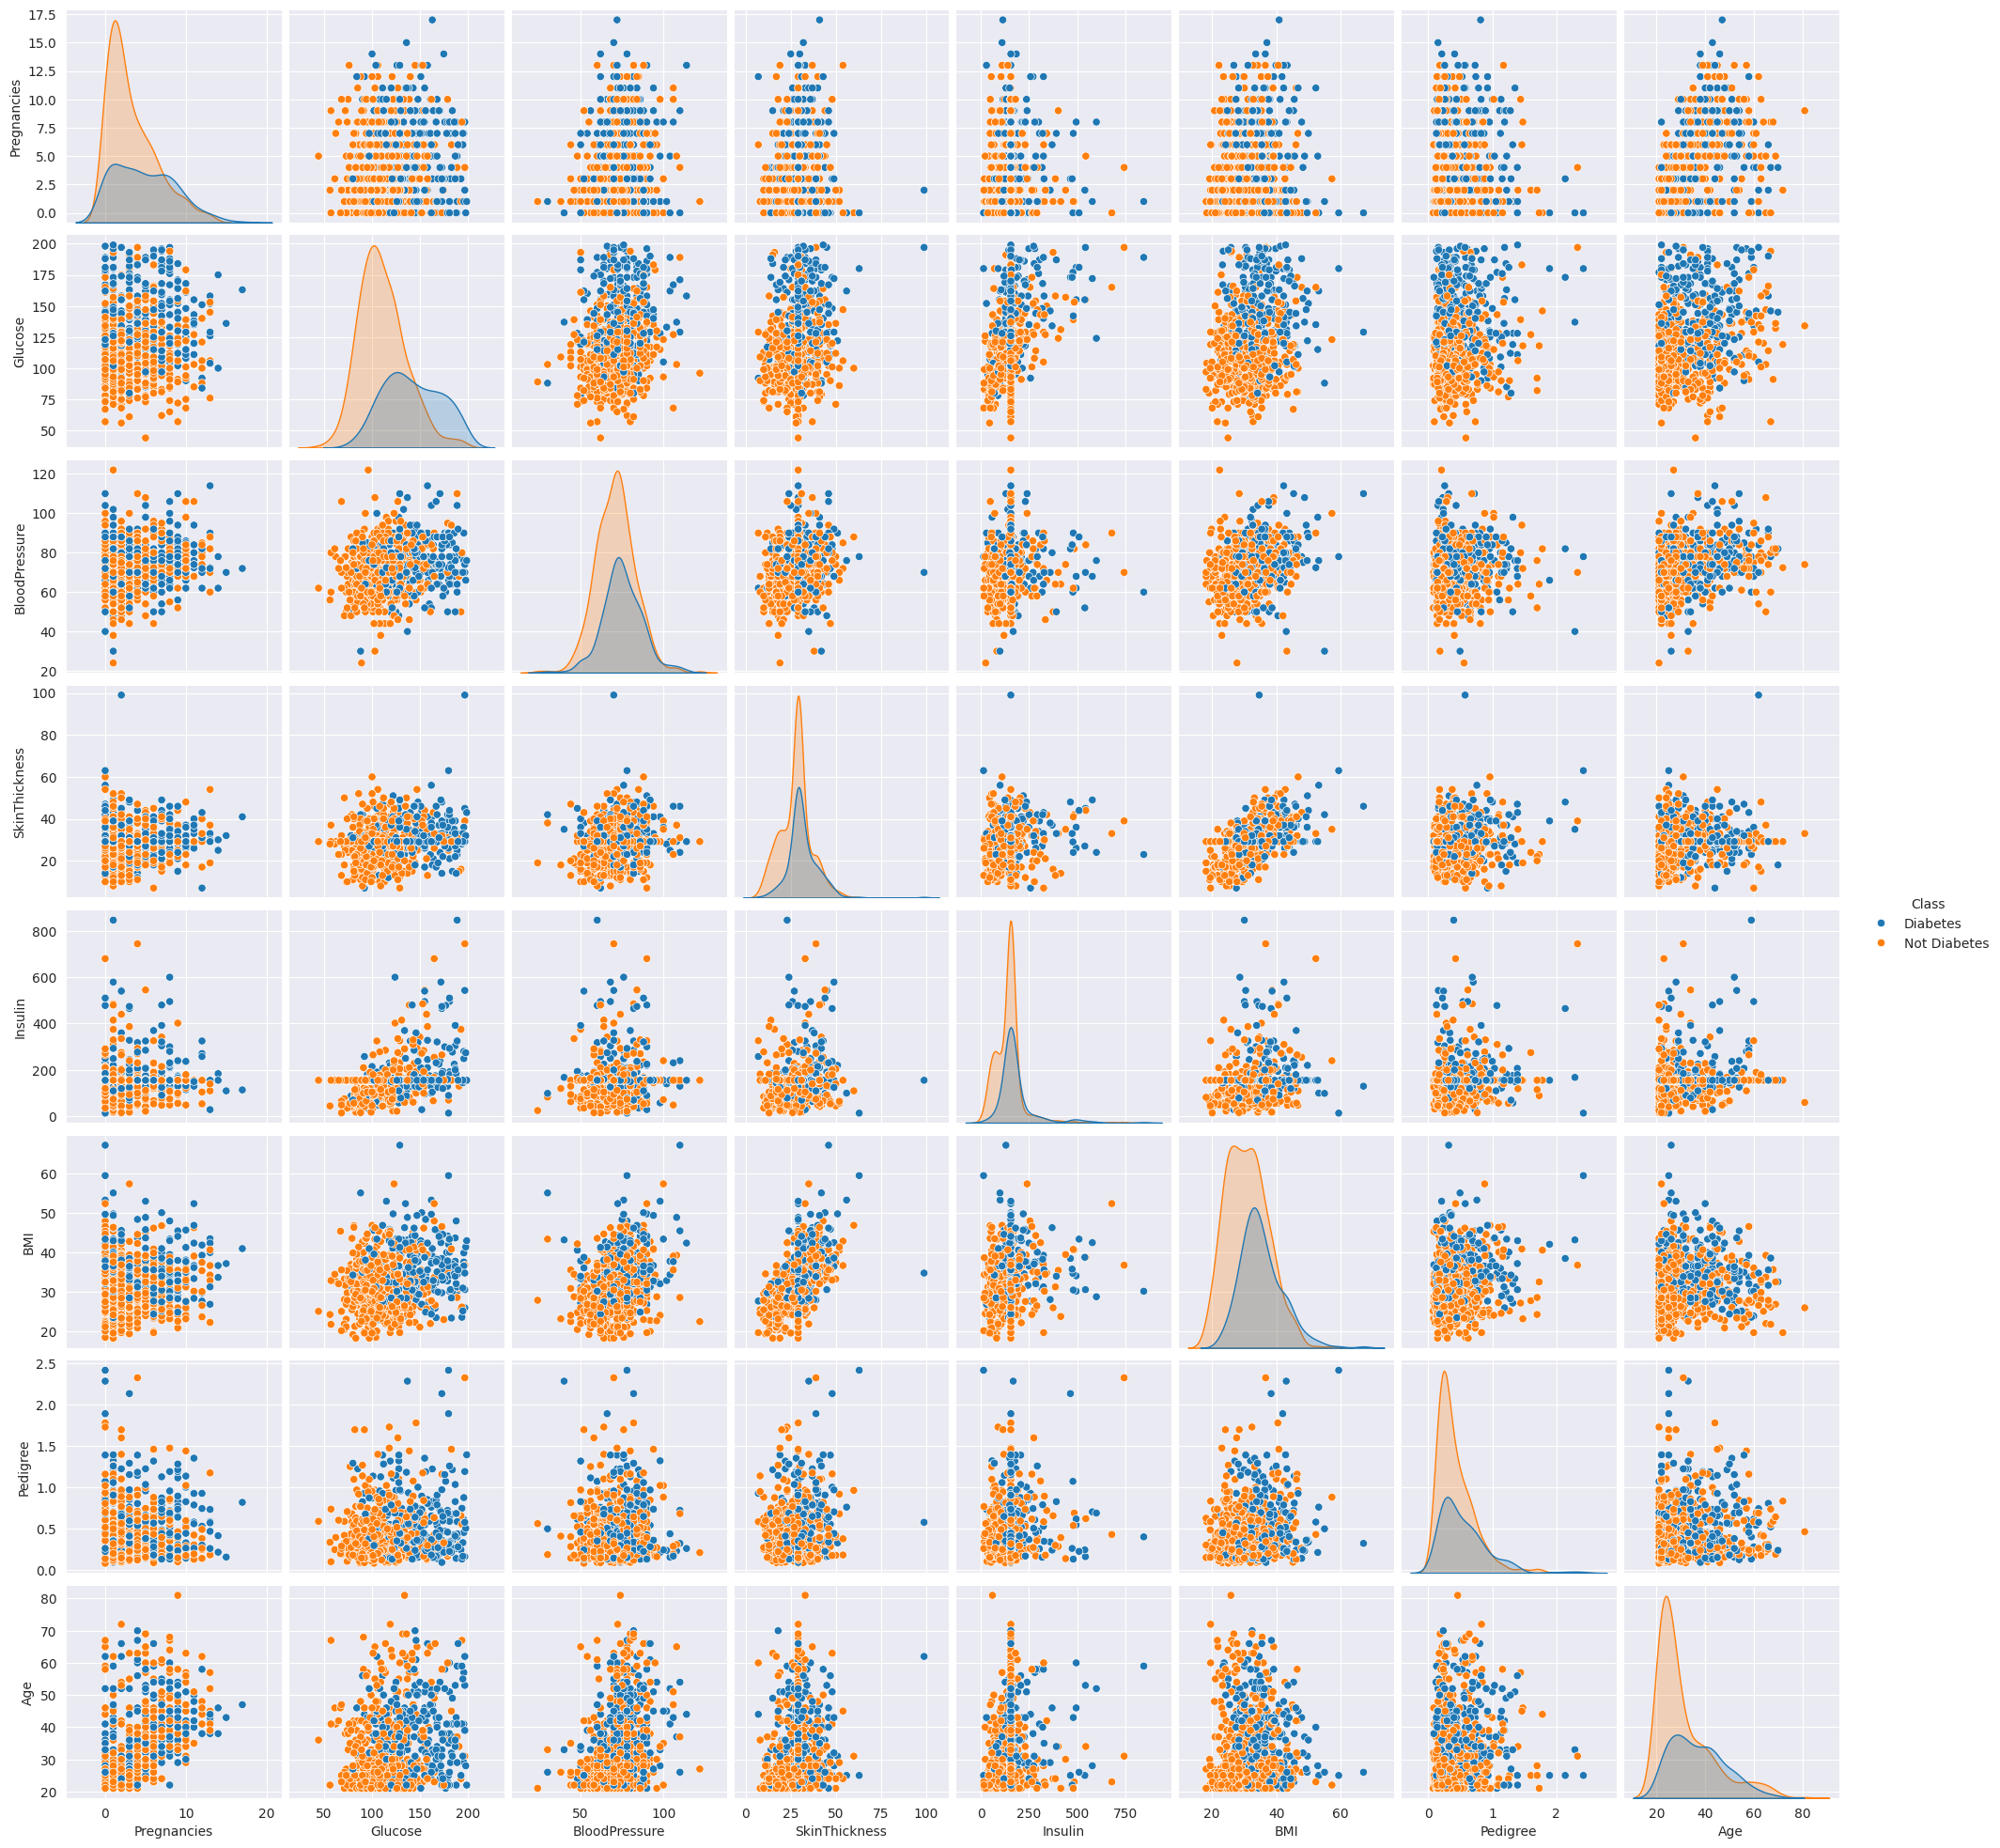

In [ ]:
# Convert target variable into meaningful labels for visualization
data["Class"] = data["Class"].map({0: "Not Diabetes", 1: "Diabetes"})

# Pairplot to visualize relationships between features, colored by diabetes class
sns.pairplot(data, hue="Class")
plt.show()

* Pregnancy and Age have a linear relation.
* Age and Blood Pressure have little relation. Most of the aged people have Blood pressure.
* Insulin and Glucose have some relation.
* The distribution plots on diagonals for Class 0 and 1 seems to overlap a little.

### Let's look at the distribution of target variable

In [ ]:
data["Class"].value_counts()

,count
Class,
Not Diabetes,500
Diabetes,268


In [ ]:
data["Class"].value_counts(1)

,proportion
Class,
Not Diabetes,0.651042
Diabetes,0.348958


* The number of observations where the person is non-diabetic are 500 which is 65% of the total data available.

In [ ]:
#Convert target to numeric BEFORE splitting
data["Class"] = data["Class"].map({"Not Diabetes": 0, "Diabetes": 1})

### Splitting data into train and test

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd

# Features and target
X = data.drop(["Class"], axis=1)
Y = data["Class"]

# Create dummy variables first
X = pd.get_dummies(X, drop_first=True)

# Add constant AFTER encoding
X = sm.add_constant(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

**The Stratify argument maintains the original distribution of classes in the target variable while splitting the data into train and test sets.**

### Fitting Logistic Regression model

In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
lg = logit.fit()

Optimization terminated successfully.
         Current function value: 0.449508
         Iterations 6


In [ ]:
print(X_train.dtypes)
print(y_train.dtype)

const            float64
Pregnancies        int64
Glucose          float64
BloodPressure    float64
SkinThickness    float64
Insulin          float64
BMI              float64
Pedigree         float64
Age                int64
dtype: object
int64


In [ ]:
# let's print the logistic regression summary
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3045
Time:                        09:13:50   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.518e-41
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7226      1.021     -9.522      0.000     -11.724      -7.721
Pregnancies       0.1445      0.039      3.706      0.000       0.068       0.221
Glucose           0.0363      0.005     

* The coefficients of the logistic regression model are in terms of log(odd).
* `P>|z|`: The interpretation of p-values is similar to that in Linear Regression.

### Checking model performance

In [ ]:
# predicting on training set
# default threshold is 0.5, if predicted probability is greater than 0.5 the observation will be classified as 1

pred_train = lg.predict(X_train) > 0.5
pred_train = np.round(pred_train)

**Let's see the Classification report on the training set**

#### Lets see the confusion matrix on training set

In [ ]:
cm = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

NameError: name 'confusion_matrix' is not defined

#### The confusion matrix

* True Positives (TP):  A person has diabetes and the model predicted person has diabetes.
* True Negatives (TN): A person doesn't have diabetes and the model predicted person doesn't have diabetes.
* False Positives (FP): The model predicted person has diabetes but the person doesn't have diabetes.
* False Negatives (FN): The model predicted person doesn't have diabetes but the person has diabetes.

#### Lets check the accuracy model

**Let's see the Classification report on the training set**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# =========================
# Predict on training set using Logit model
# =========================

# Step 1: Get predicted probabilities
# lg = fitted statsmodels Logit model
pred_train_prob = lg.predict(X_train)

# Step 2: Apply classification threshold (0.5)
# If probability > 0.5 → class = 1 (Diabetes), else 0 (Not Diabetes)
pred_train = (pred_train_prob > 0.5).astype(int)

# Step 3: Evaluate performance on training data
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       350
           1       0.73      0.61      0.66       187

    accuracy                           0.79       537
   macro avg       0.77      0.74      0.75       537
weighted avg       0.78      0.79      0.78       537



In [ ]:
#You can also run the accuracy_score()
print("Accuracy on training set : ", accuracy_score(y_train, pred_train))

Accuracy on training set :  0.7858472998137802


* The model seems to be performing well on the training set.

#### But to make interpretations from the model, first we will have to remove multicollinearity from the data to get reliable coefficients and p-values.
* There are different ways of detecting (or testing) multi-collinearity, one such way is the Variation Inflation Factor.

### Checking for Multicollinearity

In [ ]:
# let's check the VIF of the predictors
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const            55.156267
Pregnancies       1.418041
Glucose           1.358583
BloodPressure     1.226593
SkinThickness     1.446856
Insulin           1.227806
BMI               1.546783
Pedigree          1.054447
Age               1.637294
dtype: float64



* We observe that there is no multicollinearity present in the data.
* Hence, The values of coefficient and p-values are reliable.
* Let's remove the insignificant variables (p-value > 0.05) from data.

### Removing insignificant variables (p-value > 0.05 )

In [ ]:
# summary of initial logistic regression model
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3045
Time:                        09:13:50   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.518e-41
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7226      1.021     -9.522      0.000     -11.724      -7.721
Pregnancies       0.1445      0.039      3.706      0.000       0.068       0.221
Glucose           0.0363      0.005     

**Dropping SkinThickness as it has the highest p-value**

In [ ]:
X_train1 = X_train.drop("SkinThickness", axis=1)

In [ ]:
# fitting the model on training set
logit1 = sm.Logit(y_train, X_train1.astype(float))
lg1 = logit1.fit()

pred_train1 = lg1.predict(X_train1)
pred_train1 = np.round(pred_train1)


print("Accuracy on training set : ", accuracy_score(y_train, pred_train1))

Optimization terminated successfully.
         Current function value: 0.449511
         Iterations 6
Accuracy on training set :  0.7858472998137802


* There is no significant change in the model performance as compared to initial model.

In [ ]:
# checking summary of the model
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      529
Method:                           MLE   Df Model:                            7
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3045
Time:                        09:13:50   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 4.406e-42
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7189      1.018     -9.548      0.000     -11.714      -7.724
Pregnancies       0.1446      0.039      3.707      0.000       0.068       0.221
Glucose           0.0363      0.005     

**Dropping Blood Pressure with the highest p-value**

In [ ]:
X_train2 = X_train1.drop("BloodPressure", axis=1)

In [ ]:
# fitting the model on training set
logit2 = sm.Logit(y_train, X_train2.astype(float))
lg2 = logit2.fit()

pred_train2 = lg2.predict(X_train2)
pred_train2 = np.round(pred_train2)

print("Accuracy on training set : ", accuracy_score(y_train, pred_train2))

Optimization terminated successfully.
         Current function value: 0.449630
         Iterations 6
Accuracy on training set :  0.7839851024208566


* There is no significant change in the model performance as compared to initial model.

In [ ]:
## checking summary of the model
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      530
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3043
Time:                        09:13:50   Log-Likelihood:                -241.45
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 7.548e-43
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -9.8778      0.919    -10.744      0.000     -11.680      -8.076
Pregnancies     0.1442      0.039      3.702      0.000       0.068       0.220
Glucose         0.0361      0.005      7.837    

**Dropping Insulin with highest p-value**

In [ ]:
X_train3 = X_train2.drop("Insulin", axis=1)

In [ ]:
# fitting the model on training set
logit3 = sm.Logit(y_train, X_train3.astype(float))
lg3 = logit3.fit()

pred_train3 = lg3.predict(X_train3)
pred_train3 = np.round(pred_train3)

print("Accuracy on training set : ", accuracy_score(y_train, pred_train3))

Optimization terminated successfully.
         Current function value: 0.450056
         Iterations 6
Accuracy on training set :  0.7858472998137802


* There is no significant change in the model performance as compared to initial model.

In [ ]:
## checking summary of the model
print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      531
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3037
Time:                        09:13:50   Log-Likelihood:                -241.68
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 1.378e-43
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -9.8936      0.921    -10.746      0.000     -11.698      -8.089
Pregnancies     0.1440      0.039      3.686      0.000       0.067       0.221
Glucose         0.0372      0.004      8.584    

**Dropping Age with highest p-value**

In [ ]:
X_train4 = X_train3.drop("Age", axis=1)

In [ ]:
# fitting the model on training set
#logit4 = sm.Logit(y_train, X_train4.astype(float))
#lg4 = logit4.fit()

#pred_train4 = lg4.predict(X_train4)
#pred_train4 = np.round(pred_train4)

#print("Accuracy on training set : ", accuracy_score(y_train, pred_train4))

In [ ]:
# =========================
# Fit Logit model
# =========================

logit4 = sm.Logit(y_train, X_train4.astype(float))
lg4 = logit4.fit()

# =========================
# TRAINING SET PREDICTIONS
# =========================

# Predict probabilities on training set
pred_train_prob4 = lg4.predict(X_train4.astype(float))

# Convert probabilities to class labels (threshold = 0.5)
pred_train4 = (pred_train_prob4 > 0.5).astype(int)

# =========================
# TRAINING SET EVALUATION
# =========================

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy on training set:", accuracy_score(y_train, pred_train4))

print("\nClassification Report (Training Set)")
print(classification_report(y_train, pred_train4))

Optimization terminated successfully.
         Current function value: 0.451011
         Iterations 6
Accuracy on training set: 0.7821229050279329

Classification Report (Training Set)
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       350
           1       0.73      0.59      0.65       187

    accuracy                           0.78       537
   macro avg       0.77      0.74      0.75       537
weighted avg       0.78      0.78      0.78       537



* There is no significant change in the model performance as compared to initial model.

In [ ]:
## checking summary of the model
print(lg4.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.3022
Time:                        09:13:50   Log-Likelihood:                -242.19
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.951e-44
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -9.6760      0.890    -10.873      0.000     -11.420      -7.932
Pregnancies     0.1645      0.034      4.881      0.000       0.098       0.231
Glucose         0.0381      0.004      8.943    

* Now all the columns left are significant predictors, let's check the model performance and make interpretations.

### Coefficient interpretations

* Coefficient of all the variables are positive. An increase in these will lead to increase in chances of a person having diabetes.

###  Converting coefficients to odds
* The coefficients of the logistic regression model are in terms of log(odd), to find the odds we have to take the exponential of the coefficients.
* Therefore, **odds =  exp(b)**
* The percentage change in odds is given as **odds = (exp(b) - 1) * 100**

**Better explanation**

# Logistic Regression Interpretation (Odds)

# - The model estimates coefficients in terms of log-odds, not probabilities.
# - A positive coefficient means the variable increases the likelihood of diabetes.
# - A negative coefficient means it decreases the likelihood of diabetes.

# To interpret effects more clearly, we convert coefficients to odds ratios:
# Odds Ratio = exp(b)

# Interpretation of odds ratio:
# - > 1 : increases odds of diabetes
# - = 1 : no effect
# - < 1 : decreases odds of diabetes

# Percentage change in odds:
# (exp(b) - 1) * 100

**Odds from coefficients**

In [ ]:
# converting coefficients to odds
odds = np.exp(lg4.params)

# adding the odds to a dataframe
pd.DataFrame(odds, X_train4.columns, columns=["odds"]).T

,const,Pregnancies,Glucose,BMI,Pedigree
odds,0.000063,1.178781,1.038845,1.097174,2.841249


**Percentage change in odds**

In [ ]:
# finding the percentage change
perc_change_odds = (np.exp(lg4.params) - 1) * 100

# adding the change_odds% to a dataframe
pd.DataFrame(perc_change_odds, X_train4.columns, columns=["change_odds%"]).T

,const,Pregnancies,Glucose,BMI,Pedigree
change_odds%,-99.993723,17.878143,3.884519,9.717385,184.124936


### Coefficient interpretations

* `Pregnancies`: Holding all other features constant, a unit change in Pregnancy will increase the odds of a person having diabetes by 1.787 times or a 17.87% increase in the odds of having diabetes.

* `Glucose`: Holding all other features constant, a unit change in Glucose will increase the odds of a person having diabetes by 1.03 times or a 3.88% increase in the odds of having diabetes.

* `BMI`: Holding all other features constant, a unit change in BMI will increase the odds of a person having diabetes by 1.097 times or a 9.71% increase in the odds of having diabetes.

* `Pedigree`: Holding all other features constant, a unit change in Pedigree will increase the odds of a person having diabetes by 2.84 times or a 184.12% increase in the odds of having diabetes.

### Performance Metrics of the final model - 'lg4'

**Confusion Matrix on training set**

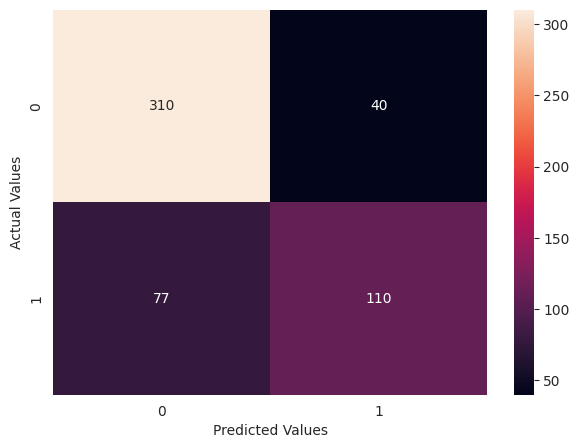

In [ ]:
cm = confusion_matrix(y_train, pred_train4)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

**Accuracy on training set**

In [ ]:
print("Accuracy on training set : ", accuracy_score(y_train, pred_train4))

Accuracy on training set :  0.7821229050279329


**ROC-AUC on training set**

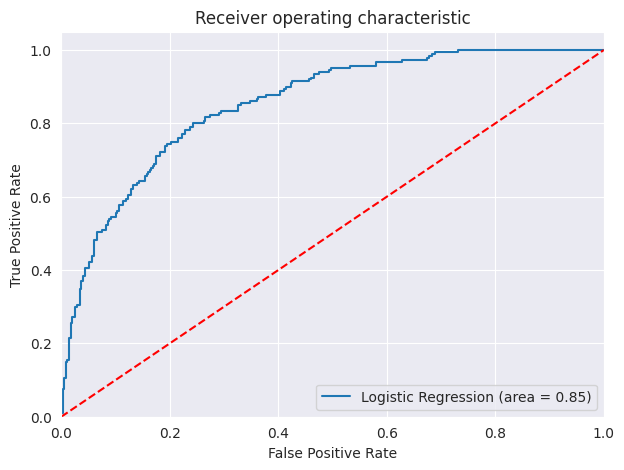

In [ ]:
logit_roc_auc_train = roc_auc_score(y_train, lg4.predict(X_train4))
fpr, tpr, thresholds = roc_curve(y_train, lg4.predict(X_train4))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

* Model is performing well on the training set.

### We can now use the model for making predictions on the test data.

In [ ]:
# Check original test columns
print(X_test.columns)

# -------------------------
# Drop same variables removed from training set
# -------------------------
X_test4 = X_test.drop(["SkinThickness", "BloodPressure", "Insulin", "Age"], axis=1)

# Verify columns
print(X_test4.columns)

# -------------------------
# TEST SET PREDICTIONS
# -------------------------

# Step 1: Predict probabilities
pred_test_prob = lg4.predict(X_test4)

# Step 2: Convert probabilities to class labels (threshold = 0.5)
pred_test = (pred_test_prob > 0.5).astype(int)

# -------------------------
# TEST SET EVALUATION
# -------------------------
from sklearn.metrics import classification_report

print("Test Set Performance")
print(classification_report(y_test, pred_test))

Index(['const', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'Pedigree', 'Age'],
      dtype='object')
Index(['const', 'Pregnancies', 'Glucose', 'BMI', 'Pedigree'], dtype='object')
Test Set Performance
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.69      0.52      0.59        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



In [ ]:
print("Accuracy on training set : ", accuracy_score(y_train, pred_train4))
print("Accuracy on test set : ", accuracy_score(y_test, pred_test))

Accuracy on training set :  0.7821229050279329
Accuracy on test set :  0.7489177489177489


* Logistic Regression has given a generalized performance on training and test set.

**Confusion Matrix on testing set**

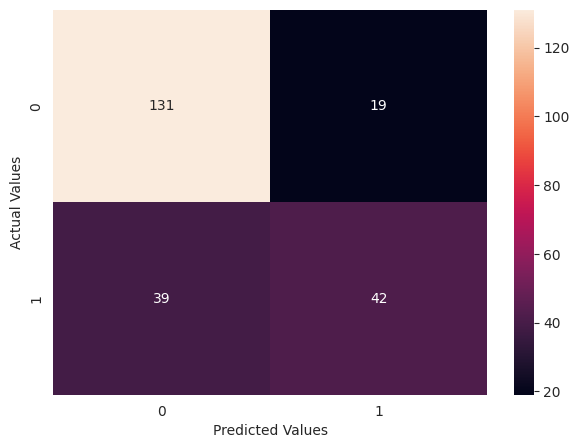

In [ ]:
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

**ROC-AUC on testing set**
    
ROC-AUC evaluates how well the model ranks predictions

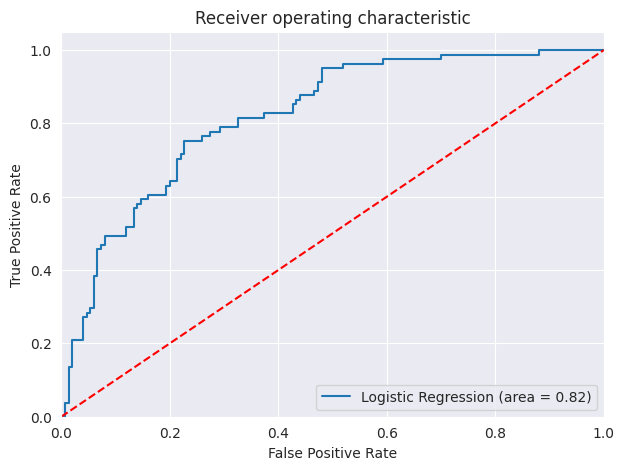

In [ ]:
logit_roc_auc_test = roc_auc_score(y_test, lg4.predict(X_test4))
fpr, tpr, thresholds = roc_curve(y_test, lg4.predict(X_test4))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_test)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()